In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder


In [362]:
# Load Data
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

In [363]:
# Show table
train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [364]:
train.value_counts("education")

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [365]:
train.value_counts("workclass")

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [366]:
train.value_counts("occupation")

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [367]:
train.value_counts("sex")

sex
Male      21790
Female    10771
Name: count, dtype: int64

In [368]:
# Replace ? with NaN
train = train.replace(" ?",np.nan)
test = test.replace(" ?",np.nan)

In [369]:
# Total Nulls
train.isna().count()

age               32561
workclass         32561
fnlwgt            32561
education         32561
education-num     32561
marital-status    32561
occupation        32561
relationship      32561
race              32561
sex               32561
capital-gain      32561
capital-loss      32561
hours-per-week    32561
native-country    32561
Income            32561
dtype: int64

In [370]:
# Calculating Duplicated Data
train.duplicated().sum()

np.int64(24)

In [371]:
# Removing Duplicated Data
train = train.drop_duplicates()

In [372]:
# Clean Column Names
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

In [373]:
# Separate features and target
x_train = train.drop("Income",axis=1)
y_train = train["Income"]

x_test = test.drop("Income",axis=1)
y_test = test["Income"]

In [374]:
# Clean target values
y_train = y_train.astype(str).str.strip().str.replace(".", "", regex=False)
y_test = y_test.astype(str).str.strip().str.replace(".", "", regex=False)

# Check values before encoding
print(y_train.unique())
print(y_test.unique())

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


In [375]:
# Encode Target
y_train = y_train.map({"<=50K": 0, ">50K": 1})
y_test = y_test.map({"<=50K": 0, ">50K": 1})

In [376]:
train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [377]:
# Drop Meaningless Features
x_train = x_train.drop(["education", "fnlwgt", "race", "capital-gain", "capital-loss","native-country"], axis=1)
x_test = x_test.drop(["education", "fnlwgt", "race", "capital-gain", "capital-loss","native-country"], axis=1)


In [378]:
x_train

,age,workclass,education-num,marital-status,occupation,relationship,sex,hours-per-week
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,Male,40
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,Male,13
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,Male,40
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,40
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Female,40
...,...,...,...,...,...,...,...,...
32556,27,Private,12,Married-civ-spouse,Tech-support,Wife,Female,38
32557,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,Male,40
32558,58,Private,9,Widowed,Adm-clerical,Unmarried,Female,40
32559,22,Private,9,Never-married,Adm-clerical,Own-child,Male,20


In [379]:
#le = LabelEncoder()

#cols_to_encode = ["workclass", "marital-status", "occupation", "relationship", "sex"]

#for col in cols_to_encode:
   # x_train[col] = le.fit_transform(x_train[col])
   # x_test[col] = le.transform(x_test[col])

   # تحديد الأعمدة categorical
cat_cols = ["workclass", "marital-status", "occupation", "relationship", "sex"]

# تطبيق OneHot
x_train = pd.get_dummies(x_train, columns=cat_cols)
x_test = pd.get_dummies(x_test, columns=cat_cols)

# توحيد الأعمدة بين train و test
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [380]:
x_train

,age,education-num,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,sex_ Female,sex_ Male
0,39,13,40,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,50,13,13,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
2,38,9,40,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,53,7,40,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,28,13,40,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,True,True,False
32557,40,9,40,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
32558,58,9,40,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
32559,22,9,20,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True


Income                                   1.000000
marital-status_ Married-civ-spouse       0.444609
relationship_ Husband                    0.400941
education-num                            0.335272
age                                      0.234037
hours-per-week                           0.229658
sex_ Male                                0.215969
occupation_ Exec-managerial              0.214889
occupation_ Prof-specialty               0.185879
workclass_ Self-emp-inc                  0.139446
relationship_ Wife                       0.123230
workclass_ Federal-gov                   0.059337
workclass_ Local-gov                     0.033027
workclass_ Self-emp-not-inc              0.030017
occupation_ Protective-serv              0.028086
occupation_ Tech-support                 0.025773
occupation_ Sales                        0.023598
workclass_ State-gov                     0.014791
marital-status_ Married-AF-spouse        0.012057
occupation_ Armed-Forces                -0.005049


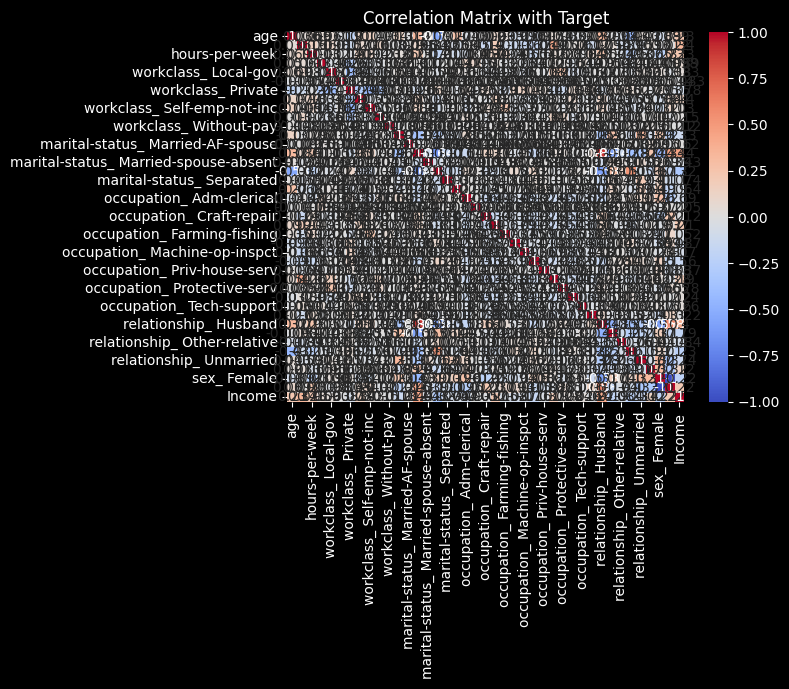

In [381]:
# Temporarily combine for correlation
train_df = pd.concat([x_train, y_train], axis=1)

# 1. Correlation with target only
corr = train_df.corr()
print(corr[y_train.name].sort_values(ascending=False))

# 2. Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Target')
plt.show()

In [382]:
# x_train = x_train.drop("sex", axis=1)
# x_test = x_test.drop("sex", axis=1)

In [383]:
x_train

,age,education-num,hours-per-week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,sex_ Female,sex_ Male
0,39,13,40,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,50,13,13,False,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,True
2,38,9,40,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,53,7,40,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,28,13,40,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,True,True,False
32557,40,9,40,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
32558,58,9,40,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
32559,22,9,20,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [384]:
# Logistic Model

# 1. Train the model
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

# 2. Predict
y_pred = model.predict(x_test)

# 3. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8350


In [385]:
# SVM Model

# 1. Train the model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train, y_train)

# 2. Predict
y_pred_svm = svm_model.predict(x_test)

# 3. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

# 4. Detailed report
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8300
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     12435
           1       0.73      0.45      0.55      3846

    accuracy                           0.83     16281
   macro avg       0.79      0.70      0.72     16281
weighted avg       0.82      0.83      0.81     16281



In [386]:
# ── Decision Tree ──────────────────────────────────────
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("===== Decision Tree =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))


===== Decision Tree =====
Accuracy: 0.7856
              precision    recall  f1-score   support

           0       0.86      0.87      0.86     12435
           1       0.55      0.53      0.54      3846

    accuracy                           0.79     16281
   macro avg       0.70      0.70      0.70     16281
weighted avg       0.78      0.79      0.78     16281



In [387]:
# ── Random Forest ──────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("===== Random Forest =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy: 0.8153
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     12435
           1       0.63      0.54      0.58      3846

    accuracy                           0.82     16281
   macro avg       0.74      0.72      0.73     16281
weighted avg       0.81      0.82      0.81     16281



In [388]:
# ── XGBoost ────────────────────────────────────────────
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("===== XGBoost =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

===== XGBoost =====
Accuracy: 0.8378
              precision    recall  f1-score   support

           0       0.88      0.91      0.90     12435
           1       0.68      0.59      0.63      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.75      0.76     16281
weighted avg       0.83      0.84      0.83     16281

